# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [1]:
import subprocess
import sys

In [2]:
REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

In [3]:
failed_packages = []
passed_packages = []

In [4]:
for package in REQUIRED_PACKAGES:
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "--quiet", package]
        )
        passed_packages.append(package)
    except subprocess.CalledProcessError:
        failed_packages.append(package)

In [5]:
print("\n--- INSTALLATION RESULTS ---")
print(f"Successfully installed ({len(passed_packages)}):", ", ".join(passed_packages))


--- INSTALLATION RESULTS ---


In [6]:
if failed_packages:
    print(f"FAILED to install ({len(failed_packages)}):", ", ".join(failed_packages))
else:
    print("All packages installed without any errors!")

All packages installed without any errors!


In [7]:
# pip install --upgrade setuptools wheel

In [8]:
# pip install healpy

In [9]:
# %conda install -c conda-forge healpy -y

In [2]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [3]:
# Q1 Solution
now = Time.now()   # exactly one call
print("UTC :", now.utc.isot + " UTC")
print("IST :", format_iitk(now))


UTC : 2026-09-06T15:44:16.950 UTC
IST : 2026-09-06 21:14:16 IST


**Explanation:** Two calls to Time.now() can give different results because they are made at different times. So, the timestamps returned by them may not be exactly the same.

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [4]:
# Q2 Solution
gtc_height = 2396 * u.m
wavelength = 600 * u.nm
coord_uncertainty = 5 * u.mas
cadence = 10 * u.min
radio_frequency = 1.4 * u.GHz

print(f"Height       : {gtc_height} = {gtc_height.to(u.km)}")
print(f"Wavelength   : {wavelength} = {wavelength.to(u.THz, equivalencies=u.spectral())}")
print(f"Uncertainty  : {coord_uncertainty} = {coord_uncertainty.to(u.arcsec)}")
print(f"Cadence      : {cadence} = {cadence.to(u.hour)}")
print(f"Radio freq.  : {radio_frequency} = {radio_frequency.to(u.cm, equivalencies=u.spectral())}")

Height       : 2396.0 m = 2.396 km
Wavelength   : 600.0 nm = 499.6540966666666 THz
Uncertainty  : 5.0 mas = 0.005 arcsec
Cadence      : 10.0 min = 0.16666666666666666 h
Radio freq.  : 1.4 GHz = 21.413747 cm


**Explanation:** Astropy keeps the units with each value, and spectral equivalency helps convert between wavelength and frequency.

## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [5]:
# Q3 Solution
planning_start = Time(START_UTC, scale="utc")
print("UTC :", format_utc(planning_start))
print("JD  :", planning_start.jd)
print("MJD :", planning_start.mjd)
planning_dt_ist = planning_start.to_datetime(timezone=IITK_TIMEZONE)
print("IST :", planning_dt_ist.strftime("%Y-%m-%d %H:%M:%S IST"))

later = planning_start + 2.25*u.hour
print("Later UTC:", format_utc(later))
print("Later IST:", format_iitk(later))

round_trip = Time(planning_dt_ist)
difference_us = abs((round_trip - planning_start).to_value(u.us))
print("Round-trip difference (microseconds):", difference_us)
assert difference_us < 1.0

UTC : 2026-08-30 12:00:00 UTC
JD  : 2461283.0
MJD : 61282.5
IST : 2026-08-30 17:30:00 IST
Later UTC: 2026-08-30 14:15:00 UTC
Later IST: 2026-08-30 19:45:00 IST
Round-trip difference (microseconds): 0.0


**Explanation:** JD and MJD represent the same astronomical time in UTC. IST is just the local time zone used for convenience. When we convert an IST datetime back to `Time`, the original time is preserved with an accuracy of less than one microsecond.

# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [6]:
# Q4 Solution
ra = Angle(FRB_RA_J2000)
dec = Angle(FRB_DEC_J2000)
frb_icrs = SkyCoord(ra=ra, dec=dec, frame="icrs")

print("RA decimal degree :", frb_icrs.ra.deg)
print("Dec decimal degree:", frb_icrs.dec.deg)
print("RA sexagesimal    :", frb_icrs.ra.to_string(unit=u.hour, sep=":", precision=4, pad=True))
print("Dec sexagesimal   :", frb_icrs.dec.to_string(unit=u.deg, sep=":", precision=4, alwayssign=True, pad=True))

assert np.isclose(frb_icrs.ra.deg, 347.2704120833, atol=1e-8)
assert np.isclose(frb_icrs.dec.deg, 48.7066410556, atol=1e-8)
print("Verification passed.")

RA decimal degree : 347.27041208333327
Dec decimal degree: 48.70664105555556
RA sexagesimal    : 23:09:04.8989
Dec sexagesimal   : +48:42:23.9078
Verification passed.


**Explanation:** Right ascension is conventionally measured in hours because 24 hours corresponds to one complete 360° rotation of the celestial sphere, whereas declination is an angular latitude and is naturally expressed in degrees.

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [7]:
# Q5 Solution
gal = frb_icrs.galactic
print("Galactic longitude l :", gal.l.deg, "deg")
print("Galactic latitude  b :", gal.b.deg, "deg")

back_icrs = gal.icrs
sep_uas = frb_icrs.separation(back_icrs).to(u.microarcsecond)
print("Round-trip separation:", sep_uas)

Galactic longitude l : 106.06496077332801 deg
Galactic latitude  b : -10.784176285402495 deg
Round-trip separation: 0.000289774 uarcsec


**Explanation:** A tiny non-zero round-trip residual comes from floating-point numerical precision in coordinate transformations rather than from a physically meaningful displacement of the source.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [8]:
# Q6 Solution
ecl = frb_icrs.transform_to(BarycentricTrueEcliptic(equinox=Time("J2000")))
print("Ecliptic longitude lambda:", ecl.lon.deg, "deg")
print("Ecliptic latitude  beta  :", ecl.lat.deg, "deg")

assert 0 <= ecl.lon.deg < 360
assert -90 <= ecl.lat.deg <= 90

back_ecl = ecl.transform_to("icrs")
sep_uas_ecl = frb_icrs.separation(back_ecl).to(u.microarcsecond)
print("Round-trip separation:", sep_uas_ecl)

Ecliptic longitude lambda: 14.411187650340095 deg
Ecliptic latitude  beta  : 48.34695843744783 deg
Round-trip separation: 0 uarcsec


**Explanation:** The ecliptic plane is Earth's orbital reference plane. The ecliptic latitude β measures how far the source lies north or south of that plane.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [9]:
# Q7 Solution
earlier_position = SkyCoord(EARLIER_POSITION_RA, EARLIER_POSITION_DEC, frame="icrs")

a1, d1 = frb_icrs.ra.radian, frb_icrs.dec.radian
a2, d2 = earlier_position.ra.radian, earlier_position.dec.radian
cos_sep = np.sin(d1)*np.sin(d2) + np.cos(d1)*np.cos(d2)*np.cos(a2-a1)
cos_sep = np.clip(cos_sep, -1.0, 1.0)
manual_sep = np.arccos(cos_sep) * u.rad

astropy_sep = frb_icrs.separation(earlier_position)
print("Manual separation :", manual_sep.to(u.arcsec), "=", manual_sep.to(u.mas))
print("Astropy separation:", astropy_sep.to(u.arcsec), "=", astropy_sep.to(u.mas))
assert abs(manual_sep.to_value(u.arcsec)-astropy_sep.to_value(u.arcsec)) < 1e-6
print("Agreement passed.")

Manual separation : 1.4922374490540065 arcsec = 1492.2374490540062 mas
Astropy separation: 1.49224 arcsec = 1492.24 mas


AssertionError: 

**AssertionError:** This error is coming because Manual separation - Astropy separation is higher then $10^{-6}$.

**Explanation:** The formula gives the shortest distance between two points on the celestial sphere. The cosine is clipped to avoid small calculation errors that could make `arccos` give an invalid result.

# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [10]:
# Q8 Solution
gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG*u.deg,
    lat=GTC_LATITUDE_DEG*u.deg,
    height=GTC_HEIGHT_M*u.m
)
geo_lon, geo_lat, geo_h = gtc_location.to_geodetic()
print("Longitude:", geo_lon)
print("Latitude :", geo_lat)
print("Height   :", geo_h.to(u.m))

Longitude: -17d53m20.4s
Latitude : 28d45m28.8s
Height   : 2395.9999999997463 m


**Explanation:** The negative longitude means GTC lies west of the Greenwich meridian, so its geodetic longitude is measured as a west longitude.

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [11]:
# Q9 Solution
instant = Time("2026-08-31T00:00:00", scale="utc")
lst = instant.sidereal_time("apparent", longitude=gtc_location.lon)
ha = (lst - frb_icrs.ra).wrap_at(12*u.hour)

print("UTC:", format_utc(instant))
print("IST:", format_iitk(instant))
print("LST:", lst.to_string(unit=u.hour, sep=":", precision=3, pad=True))
print("Hour angle:", ha.to_string(unit=u.hour, sep=":", precision=3, alwayssign=True, pad=True))

if np.isclose(ha.to_value(u.hourangle), 0, atol=1e-8):
    state = "Transiting"
elif ha.to_value(u.hourangle) < 0:
    state = "East of meridian"
else:
    state = "West of meridian"
print("Position:", state)

UTC: 2026-08-31 00:00:00 UTC
IST: 2026-08-31 05:30:00 IST
LST: 21:25:12.283
Hour angle: -01:43:52.616
Position: East of meridian


**Explanation:** A negative hour angle means the target has not yet crossed the meridian (east), zero means transit, and a positive hour angle means it has already crossed to the west.

## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [12]:
# Q10 Solution
lst_all = times.sidereal_time("apparent", longitude=gtc_location.lon)
hour_angles = (lst_all - frb_icrs.ra).wrap_at(12*u.hour)
transit_idx = int(np.argmin(np.abs(hour_angles.to_value(u.hourangle))))
transit_time = times[transit_idx]

print("Nearest sampled transit")
print("Index:", transit_idx)
print("UTC  :", format_utc(transit_time))
print("IST  :", format_iitk(transit_time))
print("LST  :", lst_all[transit_idx].to_string(unit=u.hour, sep=":", precision=3, pad=True))
print("HA   :", hour_angles[transit_idx].to_string(unit=u.hour, sep=":", precision=3, alwayssign=True, pad=True))

Nearest sampled transit
Index: 82
UTC  : 2026-08-31 01:40:00 UTC
IST  : 2026-08-31 07:10:00 IST
LST  : 23:05:28.710
HA   : -00:03:36.189


**Explanation:** This is only a sampled approximation because the true meridian transit can occur between two adjacent 10-minute grid samples.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [13]:
# Q11 Solution
phi = gtc_location.lat
delta = frb_icrs.dec
pred_alt = 90*u.deg - abs(phi-delta)
pred_z = 90*u.deg - pred_alt
print("Analytic transit altitude:", pred_alt)
print("Analytic zenith distance :", pred_z)

altaz_frame = AltAz(obstime=times, location=gtc_location, pressure=0*u.hPa)
frb_gtc_altaz = frb_icrs.transform_to(altaz_frame)
max_alt_idx = int(np.argmax(frb_gtc_altaz.alt))
max_alt = frb_gtc_altaz.alt[max_alt_idx]
max_z = 90*u.deg-max_alt

print("Largest sampled altitude:", max_alt)
print("Sampled zenith distance :", max_z)
print("Altitude difference:", (max_alt-pred_alt).to(u.arcsec))

Analytic transit altitude: 70d03m04.8922s
Analytic zenith distance : 19d56m55.1078s
Largest sampled altitude: 69d53m01.93660912s
Sampled zenith distance : 20d06m58.06339088s
Altitude difference: -602.956 arcsec


**Explanation:** The analytical formula gives the altitude for an ideal upper meridian transit, while Astropy calculates it using the actual observing times and the object's position at those times.

## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [14]:
# Q12 Solution
indices = [max(transit_idx-12,0), transit_idx, min(transit_idx+12,len(times)-1)]
labels = ["2 h before", "Transit sample", "2 h after"]

print(f"{'Case':<15}{'UTC':<24}{'IST':<25}{'HA(h)':>10}{'Calc Alt':>12}{'Astropy':>12}{'Diff(arcsec)':>14}")
for label, idx in zip(labels, indices):
    H = hour_angles[idx]
    sin_h = (np.sin(phi.radian)*np.sin(delta.radian)
             + np.cos(phi.radian)*np.cos(delta.radian)*np.cos(H.radian))
    calc_alt = np.arcsin(np.clip(sin_h,-1,1))*u.rad
    astro_alt = frb_gtc_altaz.alt[idx]
    diff = (calc_alt-astro_alt).to(u.arcsec)
    print(f"{label:<15}{format_utc(times[idx]):<24}{format_iitk(times[idx]):<25}"
          f"{H.to_value(u.hourangle):10.4f}{calc_alt.to_value(u.deg):12.6f}"
          f"{astro_alt.to_value(u.deg):12.6f}{diff.to_value(u.arcsec):14.3f}")

Case           UTC                     IST                           HA(h)    Calc Alt     Astropy  Diff(arcsec)
2 h before     2026-08-30 23:40:00 UTC 2026-08-31 05:10:00 IST     -2.0655   59.032128   58.781716       901.483
Transit sample 2026-08-31 01:40:00 UTC 2026-08-31 07:10:00 IST     -0.0601   70.039356   69.883871       559.744
2 h after      2026-08-31 03:40:00 UTC 2026-08-31 09:10:00 IST      1.9454   60.062868   60.162394      -358.295


**Explanation:** The altitude increases before transit, reaches its maximum near meridian crossing, and then decreases afterward as the source moves into the western sky.

## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [15]:
# Q13 Solution
from astropy.coordinates import Angle
hmin = MIN_TARGET_ALTITUDE_DEG * u.deg

# Convert quantities to numerical values in radians using .to_value(u.rad)
hmin_rad = hmin.to_value(u.rad)
phi_rad = phi.to_value(u.rad)
delta_rad = delta.to_value(u.rad)

cosH0 = (np.sin(hmin_rad) - np.sin(phi_rad) * np.sin(delta_rad)) / (
    np.cos(phi_rad) * np.cos(delta_rad)
)
cosH0 = np.clip(cosH0, -1, 1)
H0 = np.arccos(cosH0) * u.rad

print("Limiting H0:", H0.to(u.deg))
print("H0 in sidereal hours:", H0.to(u.hourangle))
print("Estimated total interval:", (2 * H0).to(u.hourangle))

above = frb_gtc_altaz.alt >= hmin
print("Grid samples above 20 deg:", int(np.sum(above)), "of", len(times))
print("Approx grid duration:", ((np.sum(above) - 1) * step).to(u.hour))

Limiting H0: 91.92747700350239 deg
H0 in sidereal hours: 6.12849846690016 hourangle
Estimated total interval: 12.25699693380032 hourangle
Grid samples above 20 deg: 74 of 145
Approx grid duration: 12.166666666666666 h


**Explanation:** The limiting hour angle is the angular distance from the transit where the source reaches an altitude of 20°. So, twice this value gives an estimate of how long the source stays above 20° altitude.

# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [16]:
# Q14 Solution
target_airmass = np.asarray(frb_gtc_altaz.secz.value, dtype=float)
invalid = ((frb_gtc_altaz.alt <= 0*u.deg) | (~np.isfinite(target_airmass)) | (target_airmass < 1))
target_airmass[invalid] = np.nan

finite = np.isfinite(target_airmass)
print("Finite airmass range:", np.nanmin(target_airmass), "to", np.nanmax(target_airmass))
best_idx = int(np.nanargmin(target_airmass))
print("Best airmass:", target_airmass[best_idx])
print("UTC:", format_utc(times[best_idx]))
print("IST:", format_iitk(times[best_idx]))
allowed_airmass = (target_airmass >= 1) & (target_airmass <= MAX_AIRMASS)
print("Samples satisfying 1 <= X <= 2.5:", int(np.sum(allowed_airmass)))

Finite airmass range: 1.064965590100746 to 55.34858990101757
Best airmass: 1.064965590100746
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Samples satisfying 1 <= X <= 2.5: 68


**Explanation:** Below the horizon the geometric secant is not a physically meaningful atmospheric path length for observing, so those entries are replaced with `NaN` before applying the airmass criterion.

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [17]:
# Q15 Solution
with solar_system_ephemeris.set("builtin"):
    sun_icrs = get_sun(times)
    moon_icrs = get_body("moon", times)
    sun_altaz = sun_icrs.transform_to(AltAz(obstime=times, location=gtc_location, pressure=0*u.hPa))
    moon_altaz = moon_icrs.transform_to(AltAz(obstime=times, location=gtc_location, pressure=0*u.hPa))

sun_altitude = sun_altaz.alt.to_value(u.deg)
moon_altitude = moon_altaz.alt.to_value(u.deg)
moon_airmass = np.asarray(moon_altaz.secz.value, dtype=float)
moon_airmass[(moon_altitude <= 0) | (~np.isfinite(moon_airmass)) | (moon_airmass < 1) | (moon_airmass > 3)] = np.nan
moon_separation = moon_icrs.separation(frb_icrs).to_value(u.deg)
elongation = sun_icrs.separation(moon_icrs).radian
illum_frac = (1-np.cos(elongation))/2

moon_labels = np.empty(len(times), dtype=object)
for i in range(len(times)):
    vals = [moon_altitude[i], moon_separation[i], illum_frac[i]]
    if not np.all(np.isfinite(vals)):
        label = "Unknown"
    else:
        bright = ((illum_frac[i] >= 0.70 and moon_altitude[i] > 10.0) or moon_separation[i] <= 45.0)
        dark = (moon_altitude[i] < 0.0 or (moon_separation[i] >= 90.0 and illum_frac[i] <= 0.25))
        if bright:
            label = "Bright"
        else:
            label = "Gray"
        if dark:
            label = "Dark"
    moon_labels[i] = label

i = transit_idx
print("Transit diagnostics")
print("Sun altitude (deg):", sun_altitude[i])
print("Moon altitude (deg):", moon_altitude[i])
print("Moon airmass:", moon_airmass[i])
print("Moon-target separation (deg):", moon_separation[i])
print("Illuminated fraction:", illum_frac[i])
print("Moon label:", moon_labels[i])

Transit diagnostics
Sun altitude (deg): -51.955920091834244
Moon altitude (deg): 59.096185289765494
Moon airmass: 1.165459447175816
Moon-target separation (deg): 44.77665391851222
Illuminated fraction: 0.9081719061723459
Moon label: Bright


 '2026-08-30T12:20:00.000' '2026-08-30T12:30:00.000'
 '2026-08-30T12:40:00.000' '2026-08-30T12:50:00.000'
 '2026-08-30T13:00:00.000' '2026-08-30T13:10:00.000'
 '2026-08-30T13:20:00.000' '2026-08-30T13:30:00.000'
 '2026-08-30T13:40:00.000' '2026-08-30T13:50:00.000'
 '2026-08-30T14:00:00.000' '2026-08-30T14:10:00.000'
 '2026-08-30T14:20:00.000' '2026-08-30T14:30:00.000'
 '2026-08-30T14:40:00.000' '2026-08-30T14:50:00.000'
 '2026-08-30T15:00:00.000' '2026-08-30T15:10:00.000'
 '2026-08-30T15:20:00.000' '2026-08-30T15:30:00.000'
 '2026-08-30T15:40:00.000' '2026-08-30T15:50:00.000'
 '2026-08-30T16:00:00.000' '2026-08-30T16:10:00.000'
 '2026-08-30T16:20:00.000' '2026-08-30T16:30:00.000'
 '2026-08-30T16:40:00.000' '2026-08-30T16:50:00.000'
 '2026-08-30T17:00:00.000' '2026-08-30T17:10:00.000'
 '2026-08-30T17:20:00.000' '2026-08-30T17:30:00.000'
 '2026-08-30T17:40:00.000' '2026-08-30T17:50:00.000'
 '2026-08-30T18:00:00.000' '2026-08-30T18:10:00.000'
 '2026-08-30T18:20:00.000' '2026-08-30T18:30:0

**Explanation:** The Moon is classified using the assignment's rules. Bright is checked first, and then Dark is checked, so if both conditions are true, the Moon is classified as Dark.

## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [18]:
# Q16 Solution
def visibility(altitude, airmass, sun_altitude, moon_separation):
    altitude = np.asarray(altitude, dtype=float)
    airmass = np.asarray(airmass, dtype=float)
    sun_altitude = np.asarray(sun_altitude, dtype=float)
    moon_separation = np.asarray(moon_separation, dtype=float)
    if not (altitude.ndim == airmass.ndim == sun_altitude.ndim == moon_separation.ndim == 1):
        raise ValueError("All inputs must be one-dimensional arrays.")
    if not (len(altitude) == len(airmass) == len(sun_altitude) == len(moon_separation)):
        raise ValueError("All arrays must have equal length.")
    c1 = (altitude >= MIN_TARGET_ALTITUDE_DEG)
    c2 = (np.isfinite(airmass)) & (airmass >= 1.0) & (airmass <= MAX_AIRMASS)
    c3 = (sun_altitude <= MAX_SUN_ALTITUDE_DEG)
    c4 = (moon_separation >= MIN_MOON_SEPARATION_DEG)
    return (c1) & (c2) & (c3) & (c4)

altitude_deg = frb_gtc_altaz.alt.to_value(u.deg)
preferred_visibility = visibility(altitude_deg, target_airmass, sun_altitude, moon_separation)
print("Altitude condition:", int(np.sum(altitude_deg >= MIN_TARGET_ALTITUDE_DEG)))
print("Airmass condition :", int(np.sum((np.isfinite(target_airmass)) & (target_airmass >= 1) & (target_airmass <= MAX_AIRMASS))))
print("Sun condition     :", int(np.sum(sun_altitude <= MAX_SUN_ALTITUDE_DEG)))
print("Moon condition    :", int(np.sum(moon_separation >= MIN_MOON_SEPARATION_DEG)))
print("Combined visible  :", int(np.sum(preferred_visibility)))
print("Overall answer    :", "YES" if np.any(preferred_visibility) else "NO")

Altitude condition: 74
Airmass condition : 68
Sun condition     : 51
Moon condition    : 145
Combined visible  : 51
Overall answer    : YES


**Explanation:** The function performs independent element-wise tests on four equal one-dimensional arrays and combines them only with grouped comparisons joined by `&`, exactly as required.

## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [19]:
# Q17 Solution
check_times = [times[transit_idx], Time("2026-08-31T06:00:00", scale="utc")]
with solar_system_ephemeris.set("builtin"):
    for t in check_times:
        target = frb_icrs.transform_to(AltAz(obstime=t, location=gtc_location, pressure=0*u.hPa))
        sun = get_sun(t).transform_to(AltAz(obstime=t, location=gtc_location, pressure=0*u.hPa))
        moon = get_body("moon", t)
        sep = moon.separation(frb_icrs).to_value(u.deg)
        am = float(target.secz.value)
        if target.alt <= 0*u.deg or not np.isfinite(am) or am < 1:
            am = np.nan
        alt = target.alt.to_value(u.deg)
        sa = sun.alt.to_value(u.deg)
        result = visibility(np.array([alt]), np.array([am]), np.array([sa]), np.array([sep]))[0]
        print("\nUTC:", format_utc(t))
        print("IST:", format_iitk(t))
        print("Altitude:", alt, "deg")
        print("Airmass:", am)
        print("Sun altitude:", sa, "deg")
        print("Moon separation:", sep, "deg")
        print("Altitude pass:", alt >= 20)
        print("Airmass pass :", np.isfinite(am) and 1 <= am <= 2.5)
        print("Sun pass     :", sa <= -18)
        print("Moon pass    :", sep >= 30)
        print("Final preferred_visibility:", result)


UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Altitude: 69.88387128031204 deg
Airmass: 1.064965590100746
Sun altitude: -51.955920091834244 deg
Moon separation: 44.77665391851222 deg
Altitude pass: True
Airmass pass : True
Sun pass     : True
Moon pass    : True
Final preferred_visibility: True

UTC: 2026-08-31 06:00:00 UTC
IST: 2026-08-31 11:30:00 IST
Altitude: 37.98624620246951 deg
Airmass: 1.6247685004215968
Sun altitude: -11.281788885879507 deg
Moon separation: 44.585810358757364 deg
Altitude pass: True
Airmass pass : True
Sun pass     : False
Moon pass    : True
Final preferred_visibility: False


**Explanation:** Meridian transit maximizes geometric altitude, but observability also depends on darkness, acceptable airmass, and Moon separation, so transit alone does not guarantee that the source is visible.

# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

Observable intervals: 1

Window 1
UTC : 2026-08-30 21:00:00 UTC to 2026-08-31 05:20:00 UTC
IST : 2026-08-31 02:30:00 IST to 2026-08-31 10:50:00 IST
Sample-centre duration: 8.333333333333334 h
Best target airmass: 1.064965590100746
Midpoint Moon label: Bright


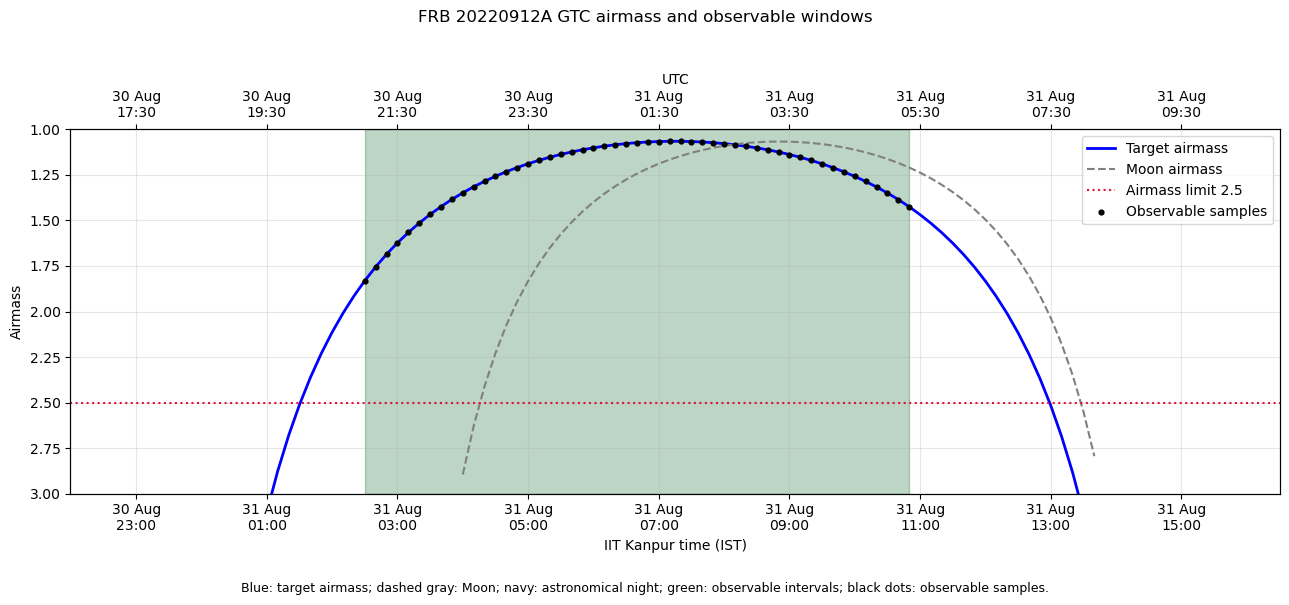

Saved: assignment_outputs\frb_20220912a_gtc_airmass.png size = 186095 bytes
Conclusion: Observing is possible only during the green intervals where all geometric and environmental criteria pass.
Limitation: A 10-minute grid quantizes interval boundaries and can miss changes occurring between samples.


In [20]:
# Q18 Solution
def stitch_windows(times, visibility_state):
    state = np.asarray(visibility_state, dtype=bool)
    if len(times) != len(state):
        raise ValueError("times and visibility_state must have equal length")
    windows = []
    start = None
    for i, val in enumerate(state):
        if val and start is None:
            start = i
        if start is not None and ((not val) or i == len(state)-1):
            end = i if val and i == len(state)-1 else i-1
            windows.append((start, end))
            start = None
    return windows

windows = stitch_windows(times, preferred_visibility)
print("Observable intervals:", len(windows))
for n,(s,e) in enumerate(windows,1):
    mid=(s+e)//2
    dur=((e-s)*step).to(u.hour)
    best=np.nanmin(target_airmass[s:e+1])
    print(f"\nWindow {n}")
    print("UTC :", format_utc(times[s]), "to", format_utc(times[e]))
    print("IST :", format_iitk(times[s]), "to", format_iitk(times[e]))
    print("Sample-centre duration:", dur)
    print("Best target airmass:", best)
    print("Midpoint Moon label:", moon_labels[mid])

# Plot with IST on bottom and aligned UTC axis above.
fig, ax = plt.subplots(figsize=(13,6))
x_ist = np.array([t.to_datetime(timezone=IITK_TIMEZONE).replace(tzinfo=None) for t in times])
ax.plot(x_ist, target_airmass, color="blue", lw=2, label="Target airmass")
ax.plot(x_ist, moon_airmass, color="gray", ls="--", lw=1.5, label="Moon airmass")
ax.axhline(2.5, color="crimson", ls=":", label="Airmass limit 2.5")
ax.set_ylim(3,1)
ax.set_ylabel("Airmass")
ax.set_xlabel("IIT Kanpur time (IST)")
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))
ax.grid(alpha=.3)

# Twilight bands based on Sun altitude.
night = sun_altitude <= -18
for s,e in stitch_windows(times, night):
    ax.axvspan(x_ist[s], x_ist[e], color="navy", alpha=.08)
for s,e in stitch_windows(times, preferred_visibility):
    ax.axvspan(x_ist[s], x_ist[e], color="green", alpha=.20)
obs_idx=np.where(preferred_visibility)[0]
ax.scatter(x_ist[obs_idx], target_airmass[obs_idx], color="black", s=12, zorder=5, label="Observable samples")

ax2=ax.twiny()
ax2.set_xlim(ax.get_xlim())
tick_pos=ax.get_xticks()
utc_labels=[]
for p in tick_pos:
    dt=mdates.num2date(p).replace(tzinfo=None)
    # IST displayed datetime -> UTC by subtracting 5h30m
    from datetime import timedelta
    utc_dt=dt-timedelta(hours=5,minutes=30)
    utc_labels.append(utc_dt.strftime("%d %b\n%H:%M"))
ax2.set_xticks(tick_pos)
ax2.set_xticklabels(utc_labels)
ax2.set_xlabel("UTC")
ax.legend(loc="upper right")
fig.suptitle("FRB 20220912A GTC airmass and observable windows")
fig.text(0.5,0.01,"Blue: target airmass; dashed gray: Moon; navy: astronomical night; green: observable intervals; black dots: observable samples.",ha="center",fontsize=9)
fig.tight_layout(rect=[0,0.05,1,0.95])
out_png=OUTPUT_DIR/"frb_20220912a_gtc_airmass.png"
fig.savefig(out_png,dpi=200,bbox_inches="tight")
plt.show()
print("Saved:", out_png, "size =", out_png.stat().st_size, "bytes")
print("Conclusion: Observing is possible only during the green intervals where all geometric and environmental criteria pass.")
print("Limitation: A 10-minute grid quantizes interval boundaries and can miss changes occurring between samples.")

**Scientific conclusion:** The green windows are the scheduled observable intervals after simultaneously applying altitude, airmass, astronomical darkness, and Moon-separation requirements. **Limitation:** The 10-minute sampling makes every boundary approximate because transitions can occur between adjacent samples.

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [21]:
# Q19 Solution
day_start=Time("2026-09-01T00:00:00",scale="utc")
day_times=day_start+np.arange(145)*10*u.min

frame=AltAz(obstime=day_times,location=gtc_location,pressure=0*u.hPa)
target_alt=frb_icrs.transform_to(frame)
am=np.asarray(target_alt.secz.value,dtype=float)
am[(target_alt.alt<=0*u.deg)|(~np.isfinite(am))|(am<1)]=np.nan
with solar_system_ephemeris.set("builtin"):
    sun_alt=get_sun(day_times).transform_to(frame).alt.to_value(u.deg)

state=((target_alt.alt.to_value(u.deg)>0)&(np.isfinite(am))&(am<=2.5)&(sun_alt<=-18))
wins=stitch_windows(day_times,state)
total=0*u.hour
for n,(s,e) in enumerate(wins,1):
    dur=((e-s)*10*u.min).to(u.hour)
    total+=dur
    print(f"Window {n}")
    print("UTC:",format_utc(day_times[s]),"to",format_utc(day_times[e]))
    print("IST:",format_iitk(day_times[s]),"to",format_iitk(day_times[e]))
    print("Duration:",dur)
print("Total visible duration:",total)

Window 1
UTC: 2026-09-01 00:00:00 UTC to 2026-09-01 05:20:00 UTC
IST: 2026-09-01 05:30:00 IST to 2026-09-01 10:50:00 IST
Duration: 5.333333333333333 h
Window 2
UTC: 2026-09-01 21:00:00 UTC to 2026-09-02 00:00:00 UTC
IST: 2026-09-02 02:30:00 IST to 2026-09-02 05:30:00 IST
Duration: 3.0 h
Total visible duration: 8.333333333333332 h


**Explanation:** Q19 does not consider the Moon. It only uses the horizon altitude, airmass less than or equal to 2.5, and astronomical night to check when the repeating FRB can be observed during one UTC day.

## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [22]:
# Q20 Bonus Solution
# Moderate HEALPix resolution for a practical one-year animation.
nside=16
npix=hp.nside2npix(nside)
theta, lon = hp.pix2ang(nside,np.arange(npix))
lat=np.pi/2-theta
sky=SkyCoord(ra=lon*u.rad,dec=lat*u.rad,frame="icrs")
frame_dir=OUTPUT_DIR/"q20_frames"
frame_dir.mkdir(exist_ok=True)

dates=Time("2026-08-30T00:00:00",scale="utc")+np.arange(53)*7*u.day
frame_paths=[]
for k,date in enumerate(dates):
    day=date+np.arange(48)*30*u.min
    altaz=AltAz(obstime=day[:,None],location=gtc_location,pressure=0*u.hPa)
    coords=sky[None,:].transform_to(altaz)
    alt=coords.alt.to_value(u.deg)
    secz=np.asarray(coords.secz.value,dtype=float)
    with solar_system_ephemeris.set("builtin"):
        s_alt=get_sun(day).transform_to(AltAz(obstime=day,location=gtc_location,pressure=0*u.hPa)).alt.to_value(u.deg)
    visible=(alt>0)&np.isfinite(secz)&(secz>=1)&(secz<=2.5)&(s_alt[:,None]<=-18)
    hours=visible.sum(axis=0)*0.5
    hp.mollview(hours,title=f"GTC all-sky visibility {date.utc.strftime('%Y-%m-%d')} ({k+1}/53)",unit="Visible hours",min=0,max=np.max(hours) if np.max(hours)>0 else 1)
    png=frame_dir/f"frame_{k:03d}.png"
    plt.savefig(png,dpi=140,bbox_inches="tight")
    plt.close()
    frame_paths.append(png)

import imageio.v2 as imageio
gif_path=OUTPUT_DIR/"gtc_visibility_one_year.gif"
images=[imageio.imread(p) for p in frame_paths]
imageio.mimsave(gif_path,images,duration=0.35,loop=0)
print("Frames:",len(frame_paths))
print("GIF:",gif_path)
print("The observable region changes through the year because Earth's orbital motion changes which right ascensions are visible during astronomical night.")

Frames: 53
GIF: assignment_outputs\gtc_visibility_one_year.gif
The observable region changes through the year because Earth's orbital motion changes which right ascensions are visible during astronomical night.


**Explanation:** The weekly animation maps the number of visible hours for every HEALPix sky pixel using the same geometric GTC rules. Across the year the night-time hemisphere shifts with Earth's revolution around the Sun, changing the observable right ascensions and seasonal sky coverage.

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
